In [14]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [15]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from imports import *
from config import dir_config, main_config
from src.glm_hmm.cv_utils import bernoulli_null_loglik, pooled_bits_per_trial, select_best_n_states

In [16]:
processed_dir = Path(dir_config.data.processed)
glm_hmm_dir = processed_dir / "glm_hmm"

from src.glm_hmm.experiments import CONFIGS

_valid_suffixes = ("__global_pooled_cv", "__session_pooled_cv")
MODEL_PATHS = {
    f.stem: f for f in glm_hmm_dir.iterdir()
    if f.is_dir()
    and any(f.stem.endswith(s) for s in _valid_suffixes)
    and f.stem.replace("__global_pooled_cv", "").replace("__session_pooled_cv", "") in CONFIGS
}

In [17]:
def session_bits(bundle):
    """Session-wise CV: bits/trial computed per session then averaged (mean, SEM across sessions)."""
    sw = bundle["session_wise"]
    states = np.array(list(sw["models"][0].keys()))
    n_trials, null = [], []
    for df in bundle["data"].values():
        valid = ~df["invalid_idx"].values
        y = df["choices"].values[valid]
        p = np.clip(y.mean(), 1e-6, 1 - 1e-6)
        n_trials.append(int(valid.sum()))
        null.append((y * np.log(p) + (1 - y) * np.log(1 - p)).sum())
    n_trials, null = np.array(n_trials), np.array(null)
    bits = (sw["test_ll"].sum(2) - null[:, None]) / (n_trials[:, None] * np.log(2))
    return states, bits.mean(0), bits.std(0) / np.sqrt(bits.shape[0])

def session_train_bits(bundle):
    """Session-wise CV training bits/trial, averaged over sessions and folds.

    Train folds overlap (each leaves out one fold), so they cannot be summed into one pass
    like the test folds. We score each (session, state, fold) and average; the per-fold train
    size and null are approximated as (k-1)/k of the session's valid trials (k-fold split).
    """
    sw = bundle["session_wise"]
    states = np.array(list(sw["models"][0].keys()))
    k_folds = sw["train_ll"].shape[2]
    frac = (k_folds - 1) / k_folds
    n_trials, null = [], []
    for df in bundle["data"].values():
        valid = ~df["invalid_idx"].values
        y = df["choices"].values[valid]
        p = np.clip(y.mean(), 1e-6, 1 - 1e-6)
        n_trials.append(int(valid.sum()))
        null.append((y * np.log(p) + (1 - y) * np.log(1 - p)).sum())
    n_trials = np.array(n_trials)[:, None, None]
    null = np.array(null)[:, None, None]
    bits_fold = (sw["train_ll"] - null * frac) / (n_trials * frac * np.log(2))  # (sessions, states, folds)
    n = np.sum(~np.isnan(bits_fold), axis=(0, 2))
    return states, np.nanmean(bits_fold, axis=(0, 2)), np.nanstd(bits_fold, axis=(0, 2)) / np.sqrt(n)

def pooled_bits(bundle):
    """Pooled CV: (states, mean_bits, sem_bits) over one held-out pass, vs the Bernoulli null."""
    gpc = bundle["group_pooled_cv"]
    null_ll, n_valid = bernoulli_null_loglik(bundle["data"])
    mean_bits, sem_bits = pooled_bits_per_trial(gpc["test_ll"], gpc["n_test_trials"], null_ll, n_valid)
    return np.asarray(gpc["state_range"]), mean_bits, sem_bits

def pooled_train_bits(bundle):
    """Pooled CV training bits/trial per state (mean, SEM across folds), vs the Bernoulli null.

    Train folds overlap, so they are scored per fold (each normalized by its own train-trial
    count and a proportional null) and averaged, rather than summed into one pass.
    """
    gpc = bundle["group_pooled_cv"]
    null_ll, n_valid = bernoulli_null_loglik(bundle["data"])
    train_ll, n_train = gpc["train_ll"], gpc["n_train_trials"]
    bits_fold = (train_ll - null_ll * (n_train / n_valid)) / (n_train * np.log(2))  # (states, folds)
    return np.asarray(gpc["state_range"]), bits_fold.mean(1), bits_fold.std(1) / np.sqrt(bits_fold.shape[1])

def parsimonious_k(states, mean_bits, sem_bits):
    """Smallest K within 1 SEM (or tol) of the peak; mirrors cv_utils.select_best_n_states."""
    best_idx = int(np.argmax(mean_bits))
    cutoff = mean_bits[best_idx] - sem_bits[best_idx]
    chosen_idx = next(i for i in range(best_idx + 1) if mean_bits[i] >= cutoff)
    return int(states[chosen_idx]), int(states[best_idx])

def plot_test_ll_bits(
    states,
    mean_bits,
    sem_bits,
    title="",
    best_k=None,
    train=None,
    ax=None,
):
    if ax is None:
        ax = plt.gca()

    TEST_C, TRAIN_C = "tab:blue", "tab:orange"
    test_line = ax.errorbar(states, mean_bits, yerr=sem_bits, marker="o", markersize=9, linewidth=2.5, capsize=4, color=TEST_C, label="test")

    if best_k is not None:
        # plot a box around the best K value
        best_idx = np.where(states == best_k)[0][0]
        ax.plot(states[best_idx], mean_bits[best_idx], marker="o", markersize=15, markerfacecolor="none", markeredgecolor="red", markeredgewidth=2)
    ax.axhline(0, color="black", linewidth=1, linestyle=":")  # Bernoulli (coin-flip) null
    ax.set_xlabel("Number of States", fontsize=20)
    ax.set_ylabel("Test LL (bits/trial)", fontsize=20, color=TEST_C)
    ax.tick_params(labelsize=15)
    ax.tick_params(axis="y", labelcolor=TEST_C)
    ax.spines["top"].set_visible(False)

    handles = [test_line]
    if train is not None:
        # Train bits/trial overlaid on an independent right-hand axis (typically higher: overfitting).
        train_mean, train_sem = train
        ax2 = ax.twinx()
        train_line = ax2.errorbar(states, train_mean, yerr=train_sem, marker="s", markersize=8, linewidth=2, linestyle="--", capsize=4, color=TRAIN_C, label="train")
        ax2.set_ylabel("Train LL (bits/trial)", fontsize=20, color=TRAIN_C)
        ax2.tick_params(labelsize=15, axis="y", labelcolor=TRAIN_C)
        ax2.spines["top"].set_visible(False)
        handles.append(train_line)
    else:
        ax.spines["right"].set_visible(False)

    xticks = states.astype(int)
    if xticks is not None:
        ax.set_xticks(xticks)
    ax.legend(handles=handles, labels=[h.get_label() for h in handles], fontsize=12, loc="lower right", frameon=False)
    ax.set_title(title, fontsize=20)

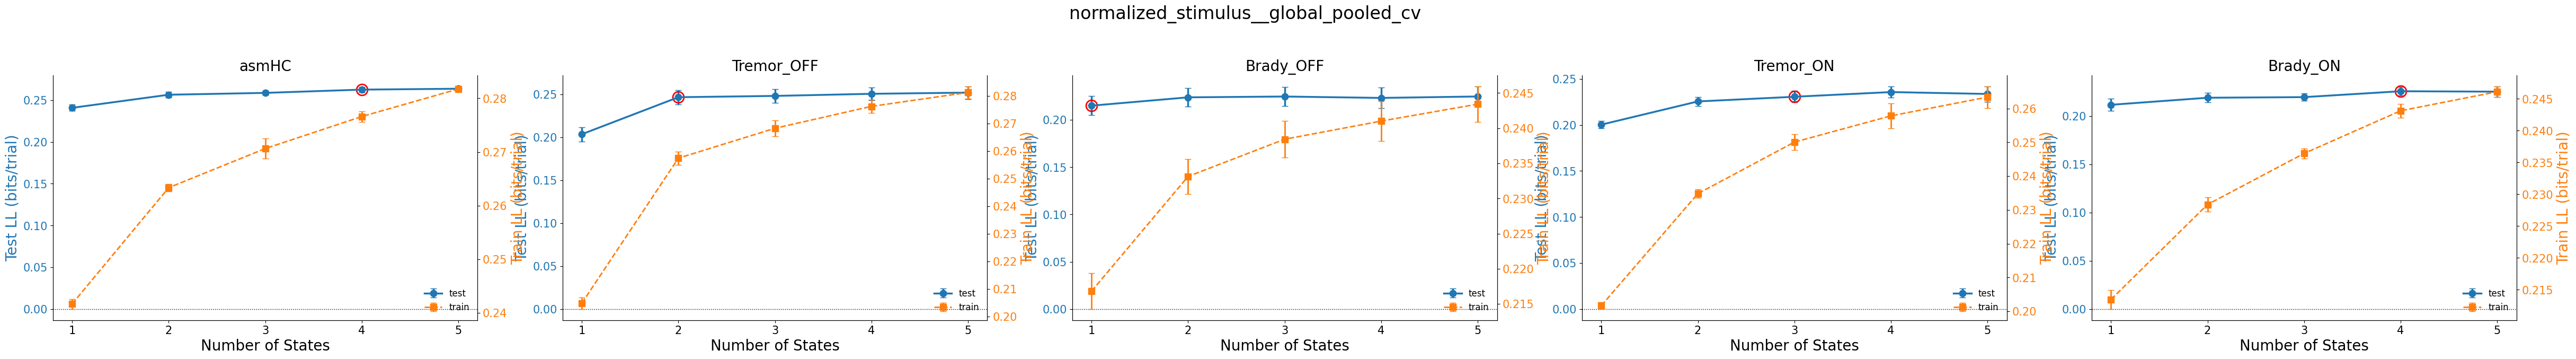

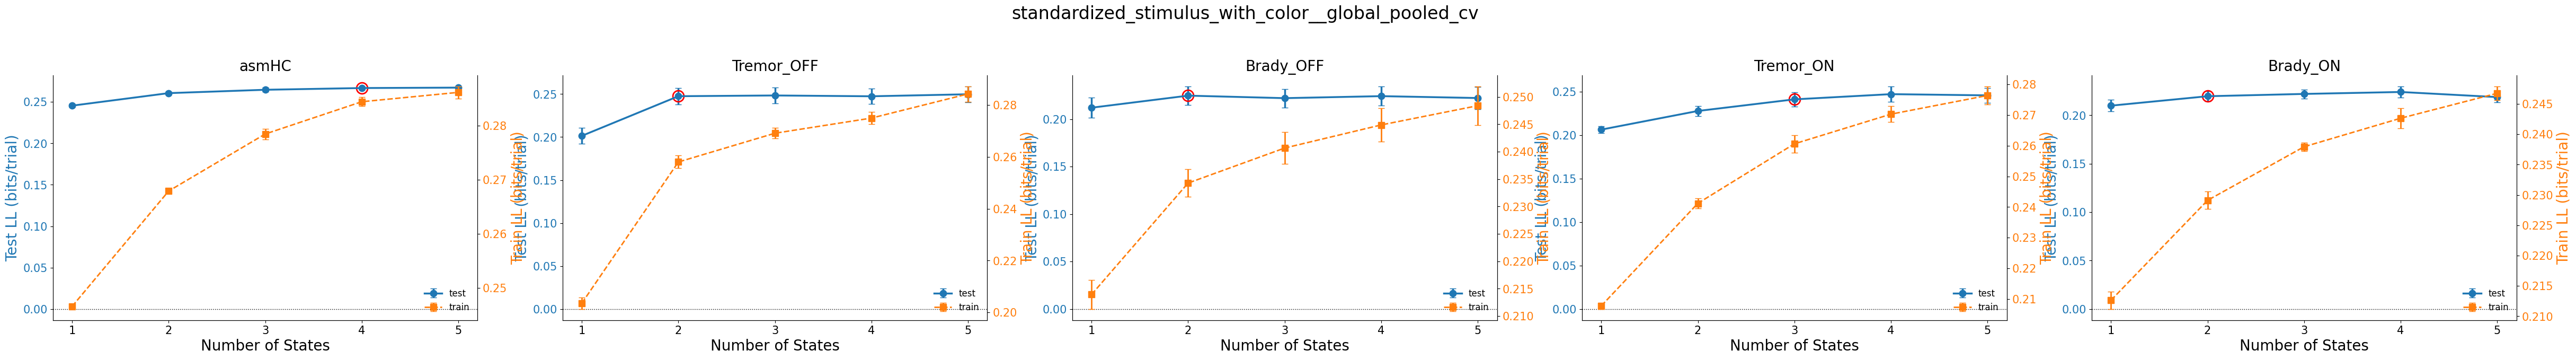

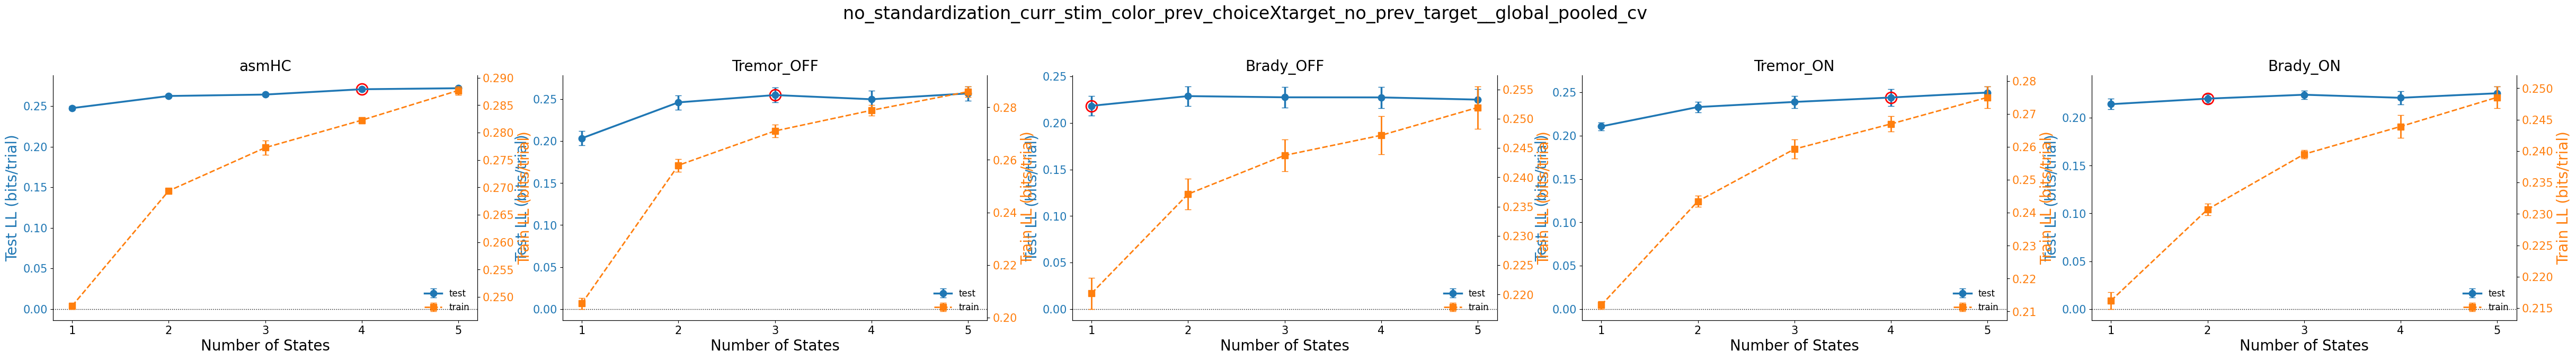

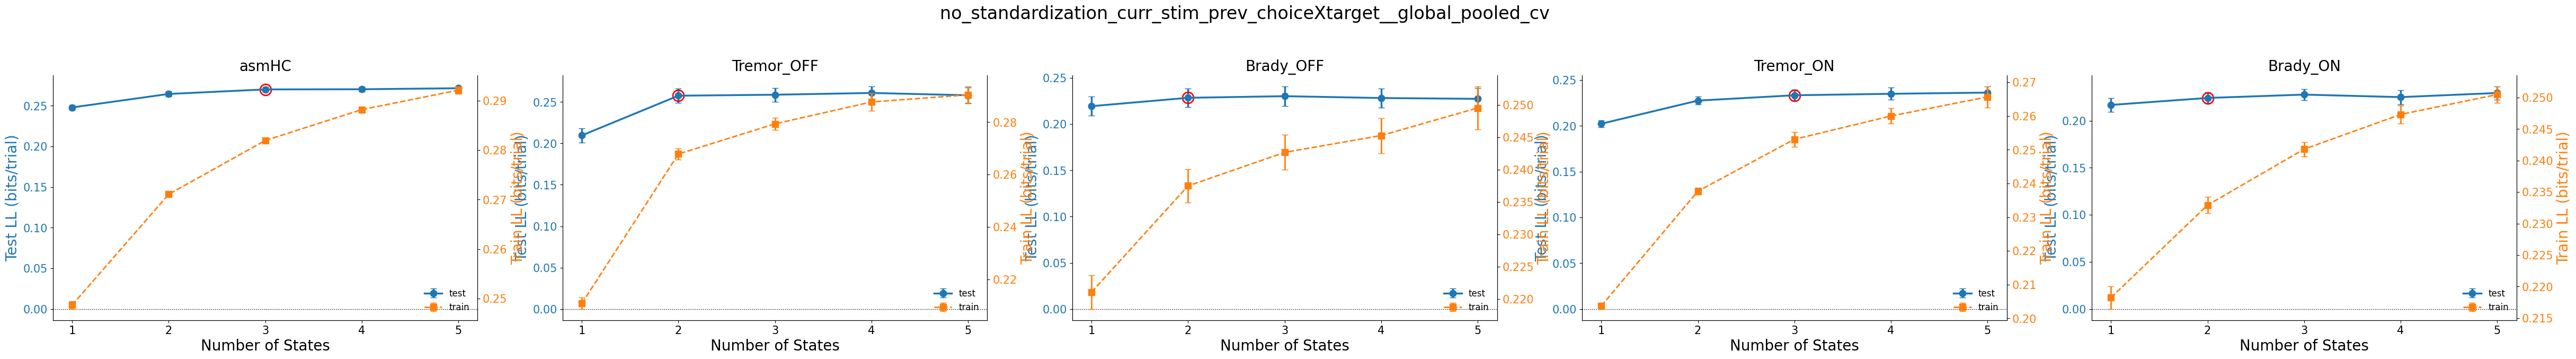

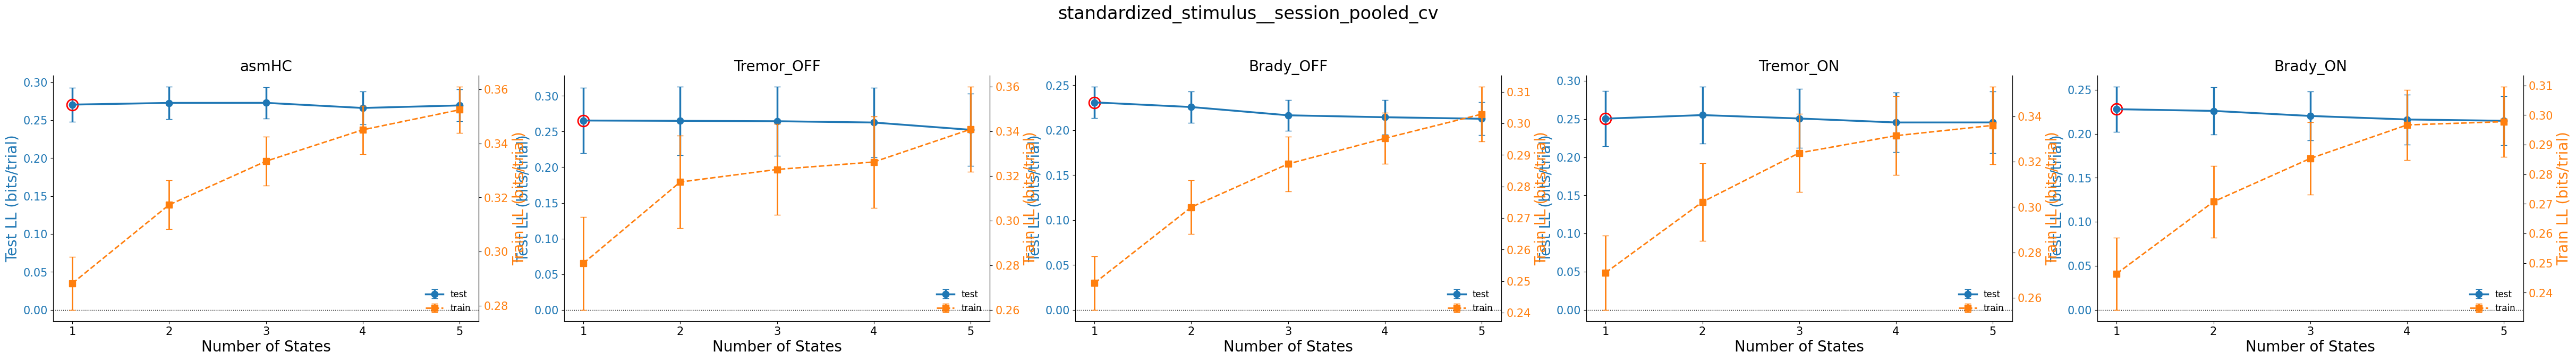

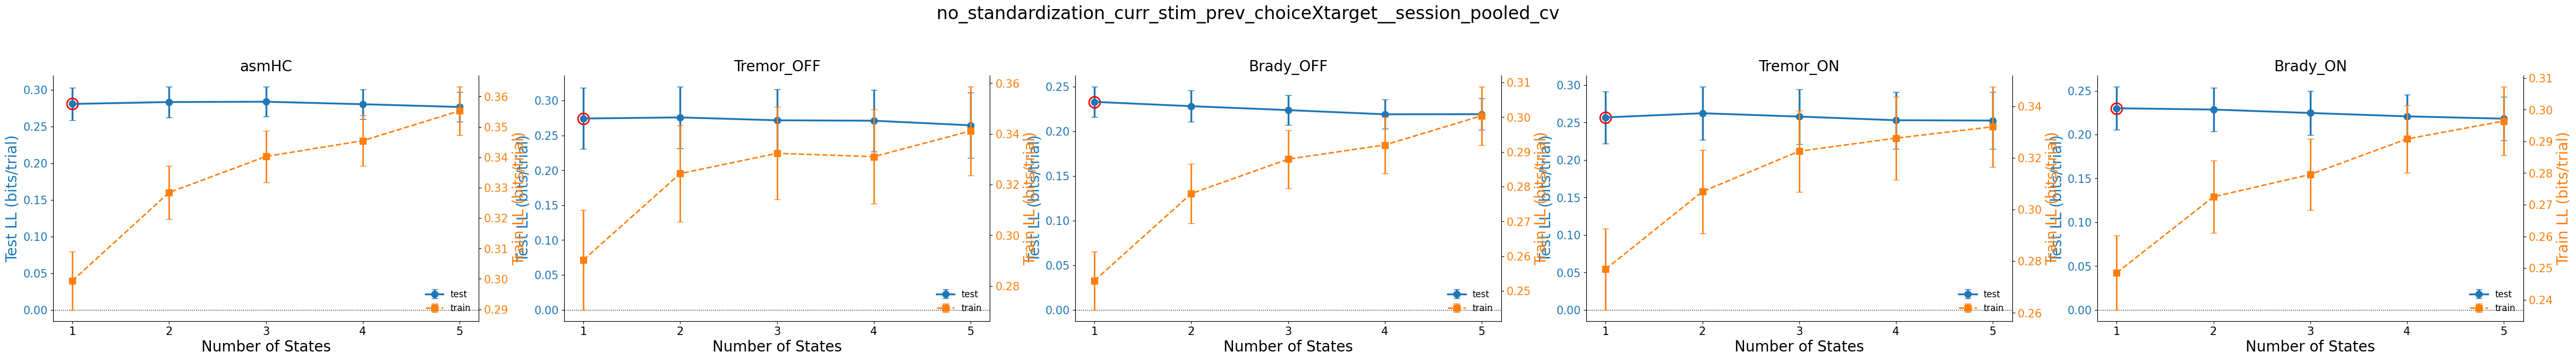

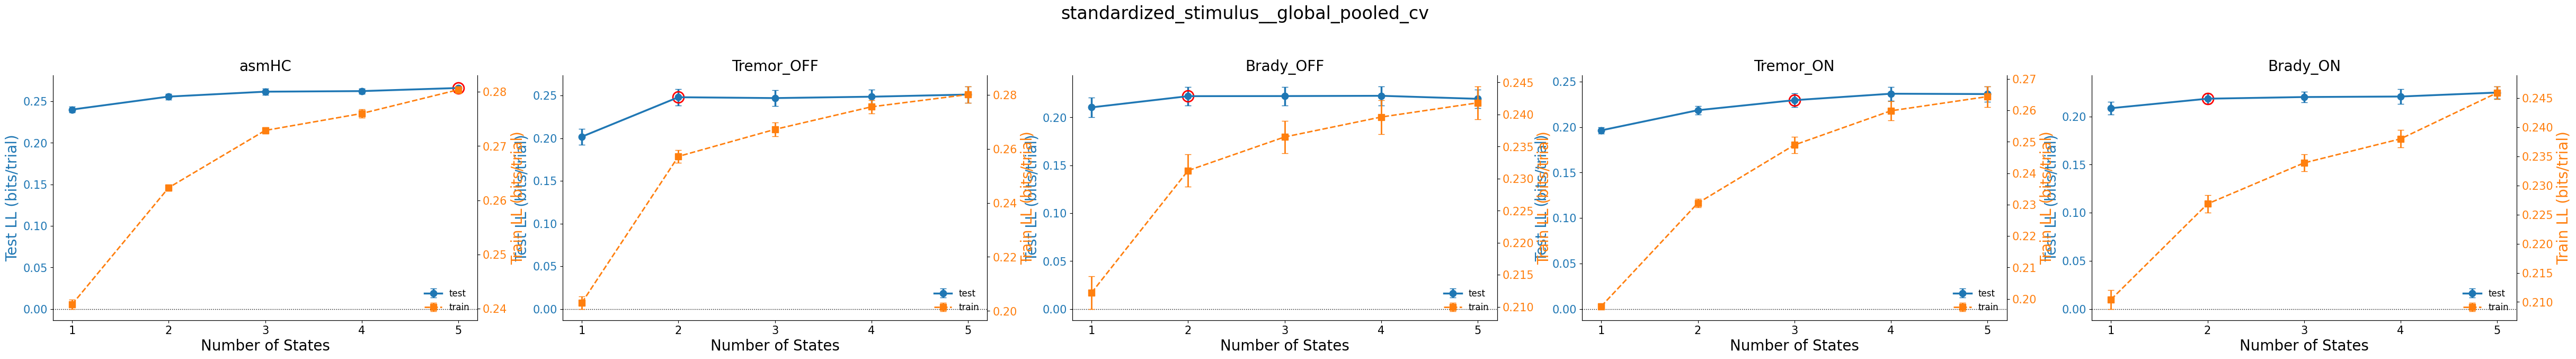

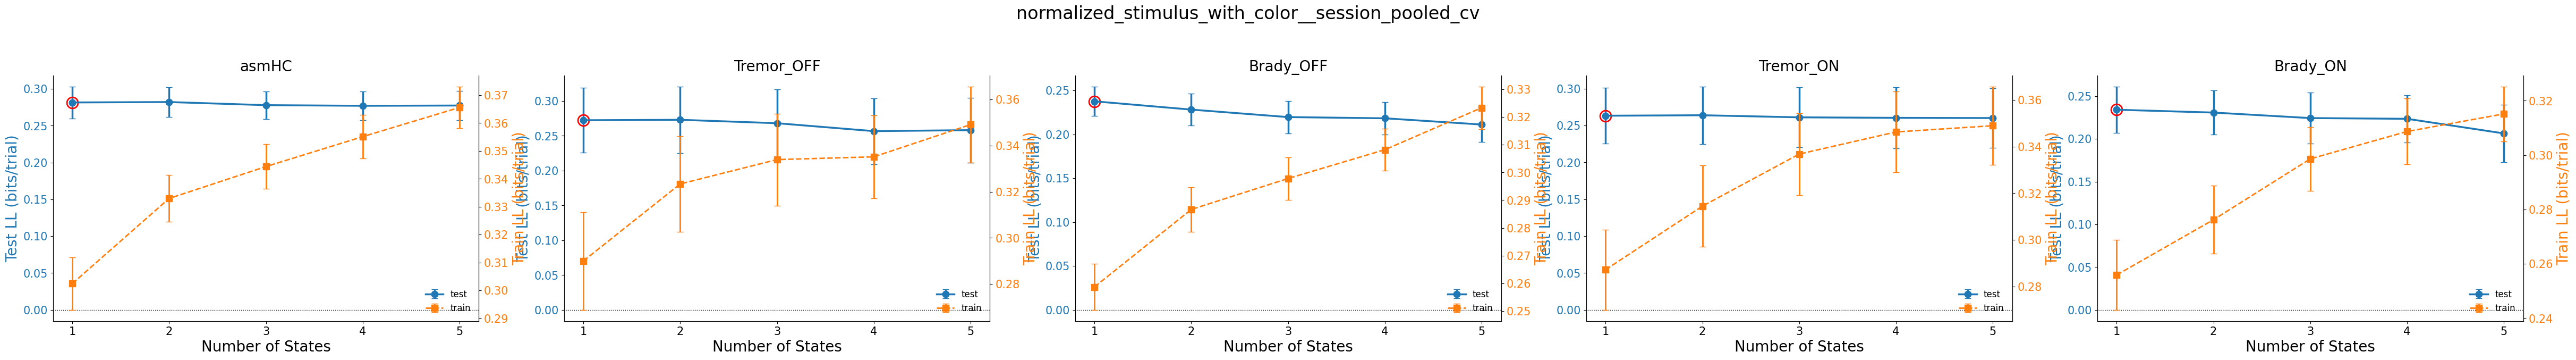

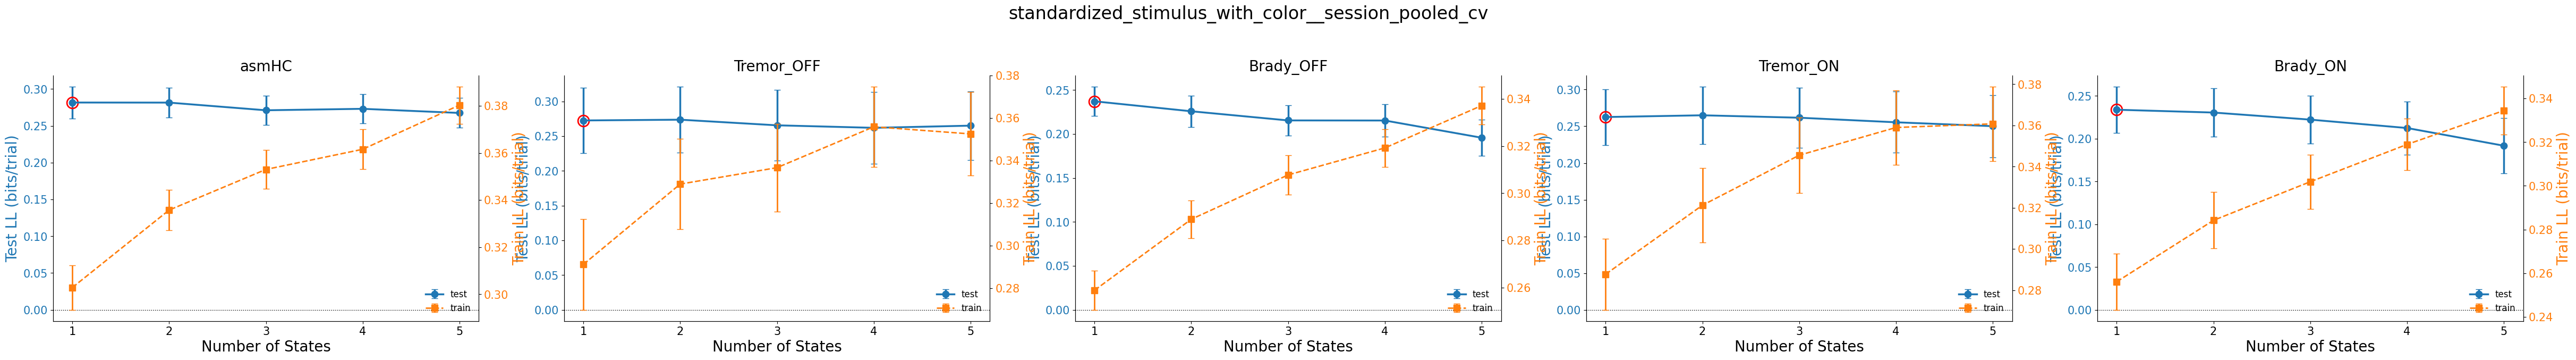

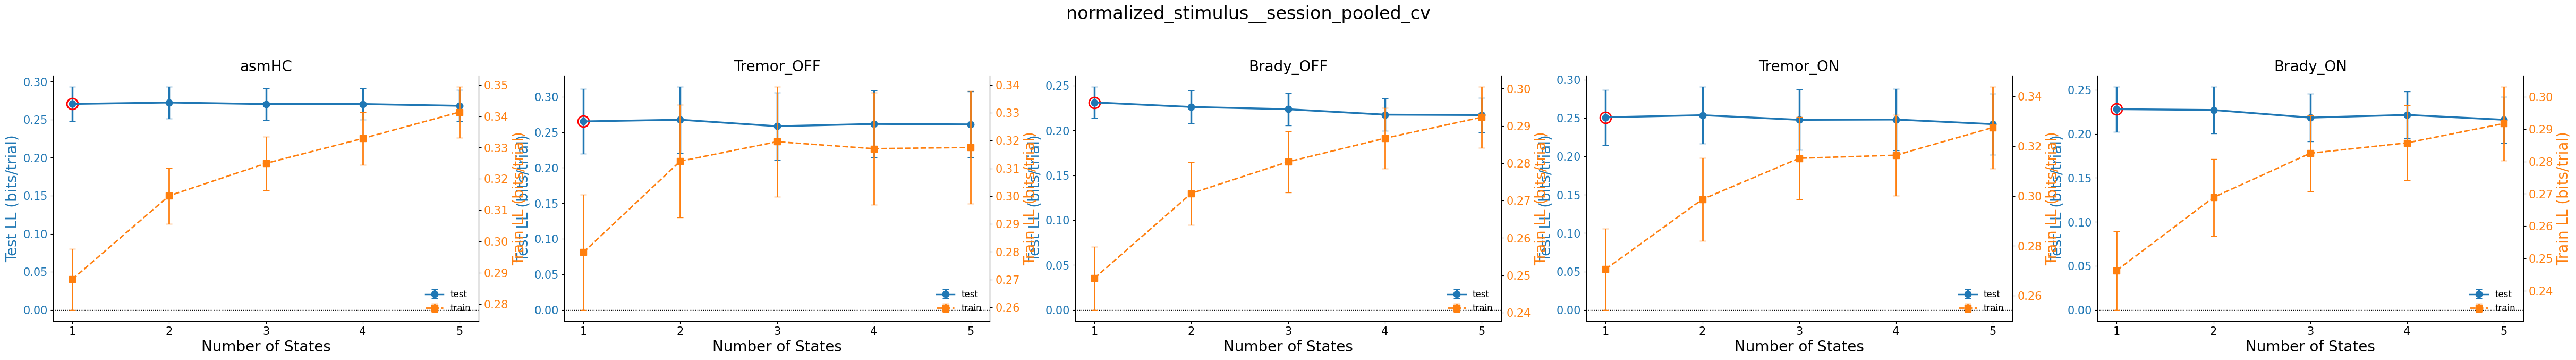

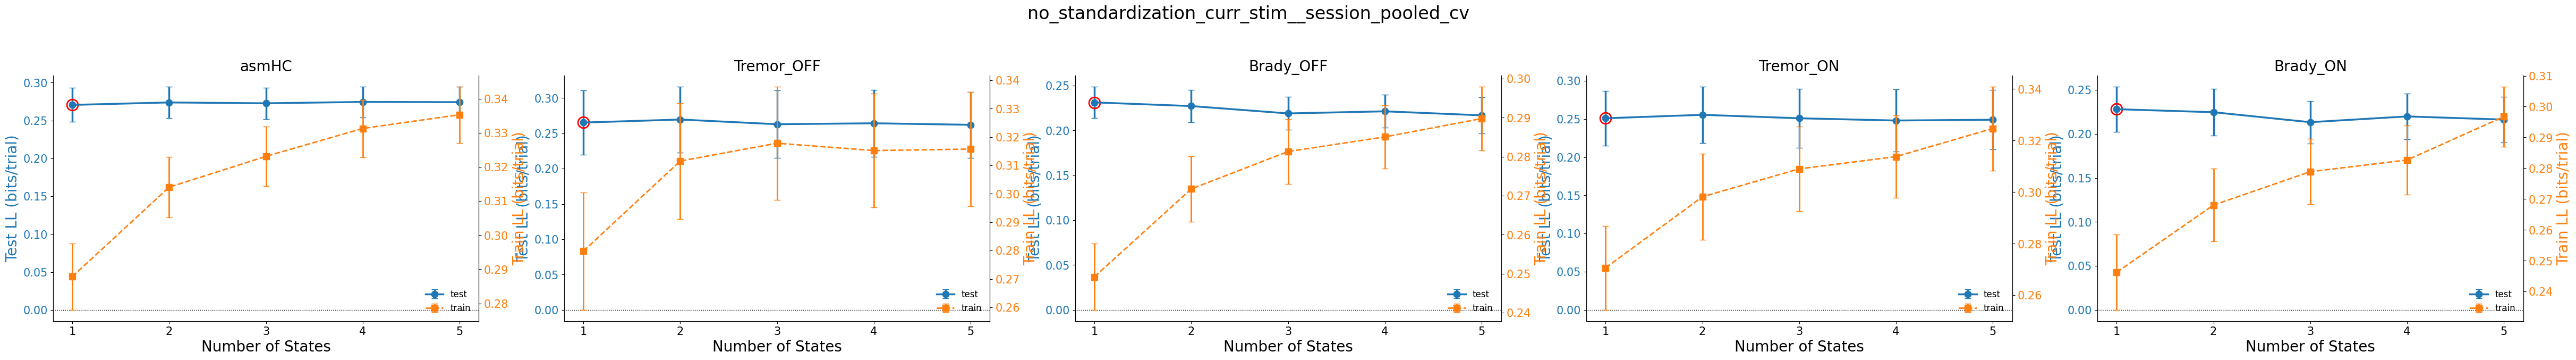

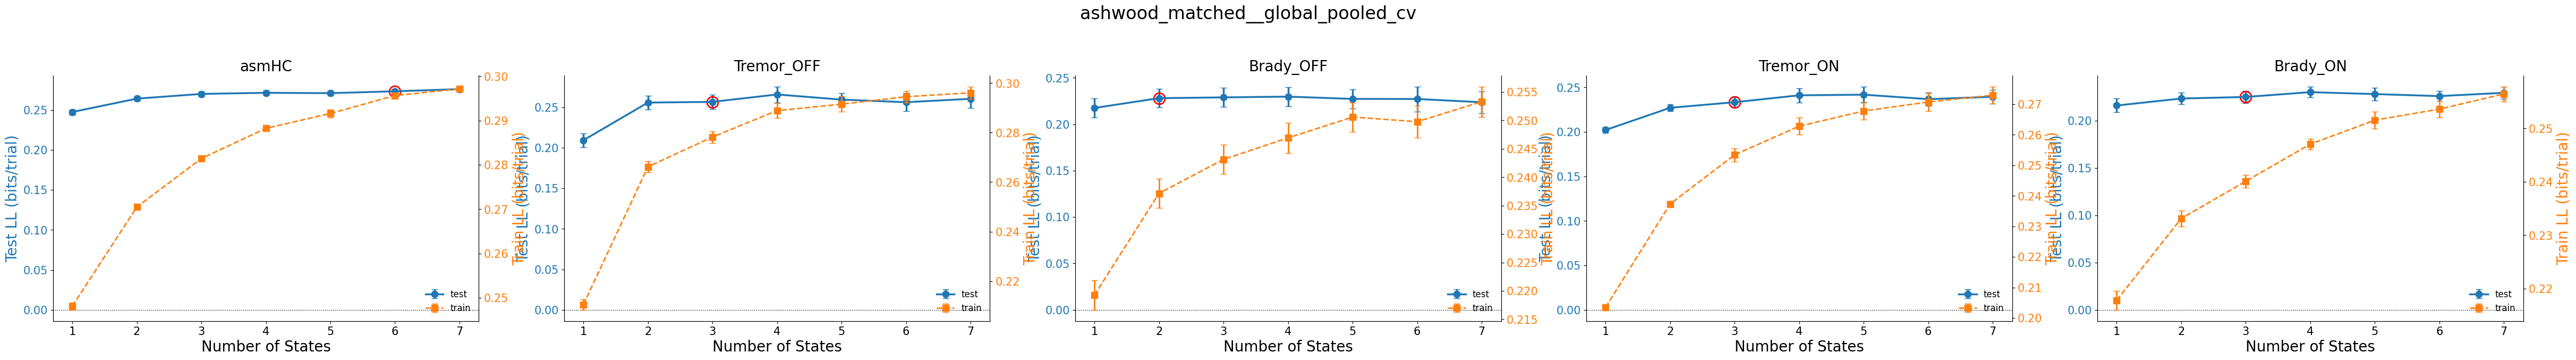

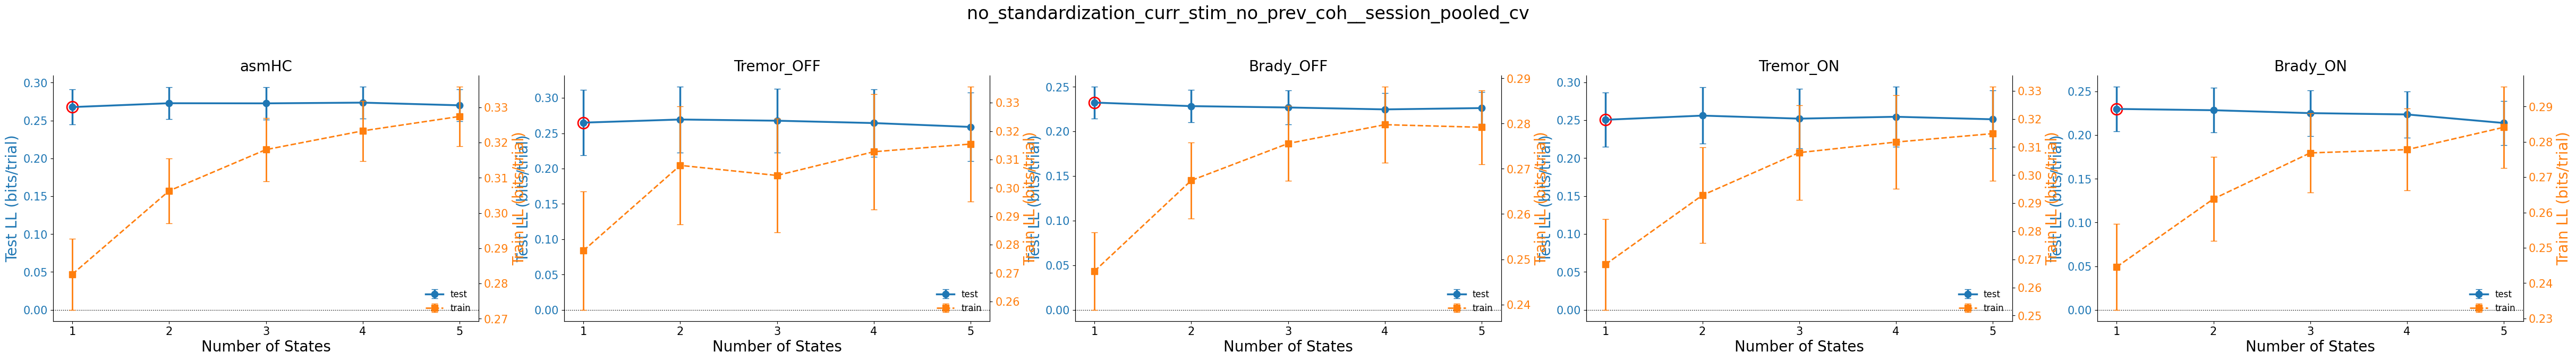

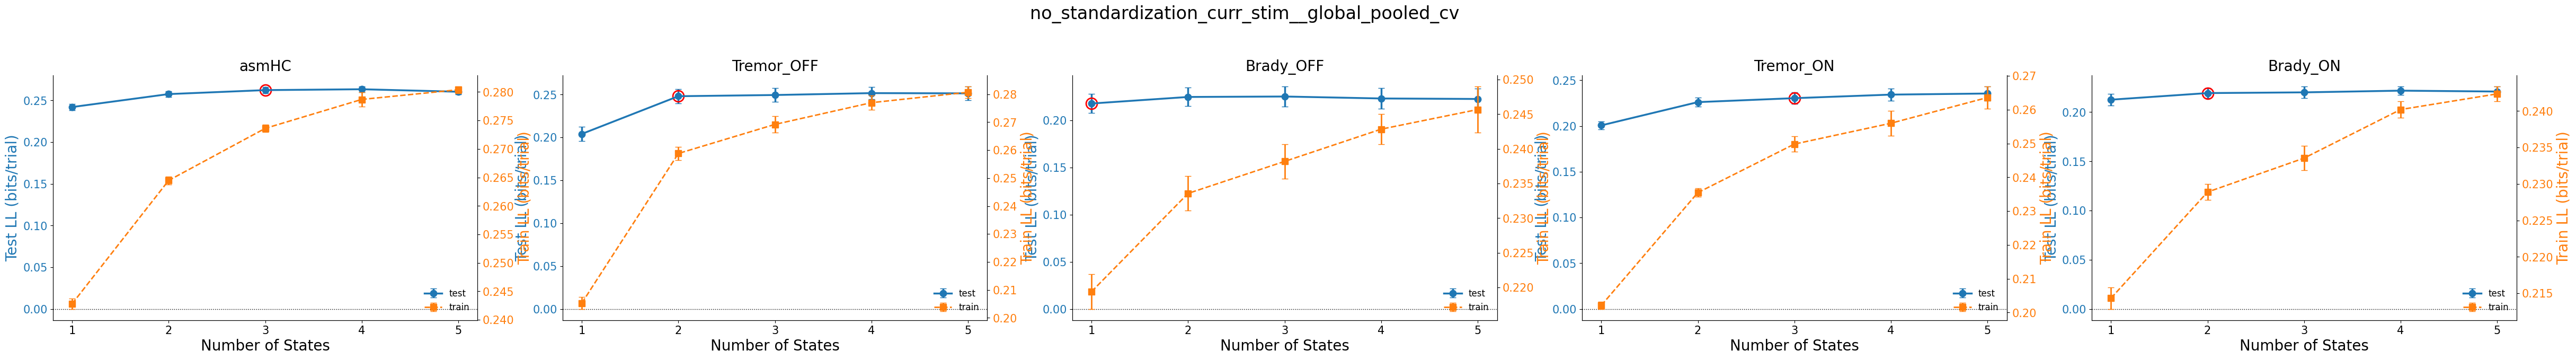

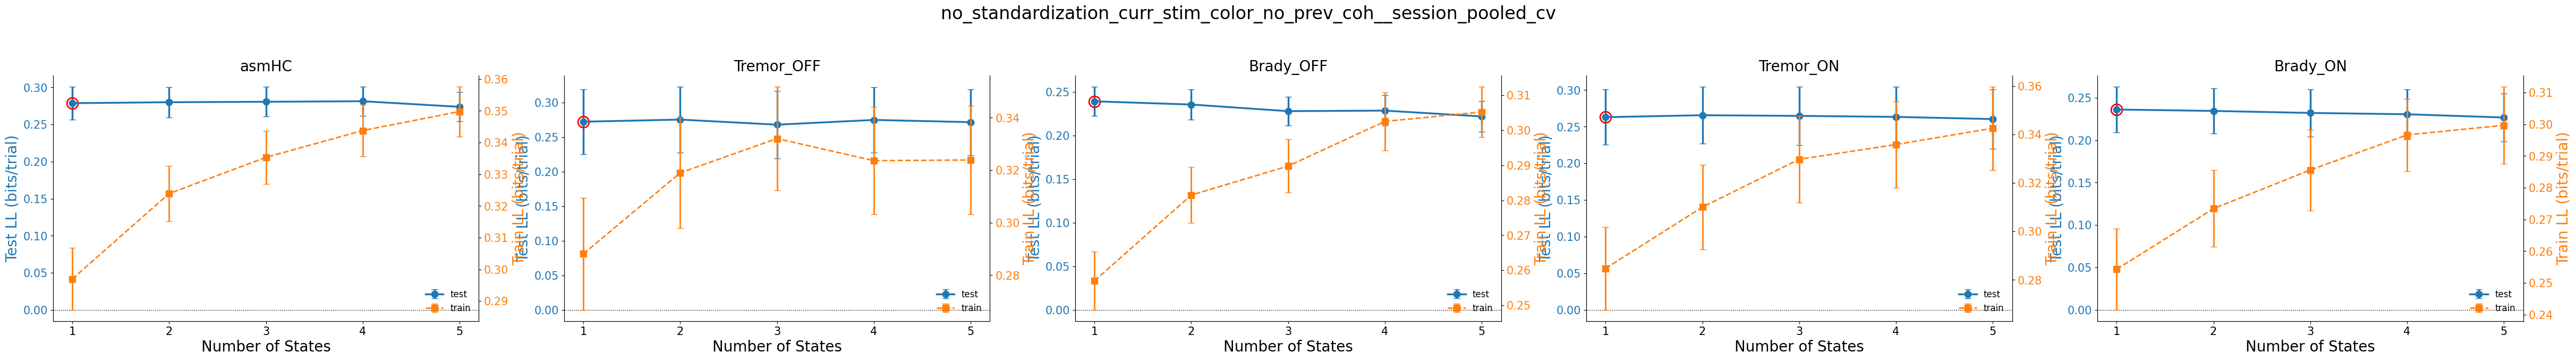

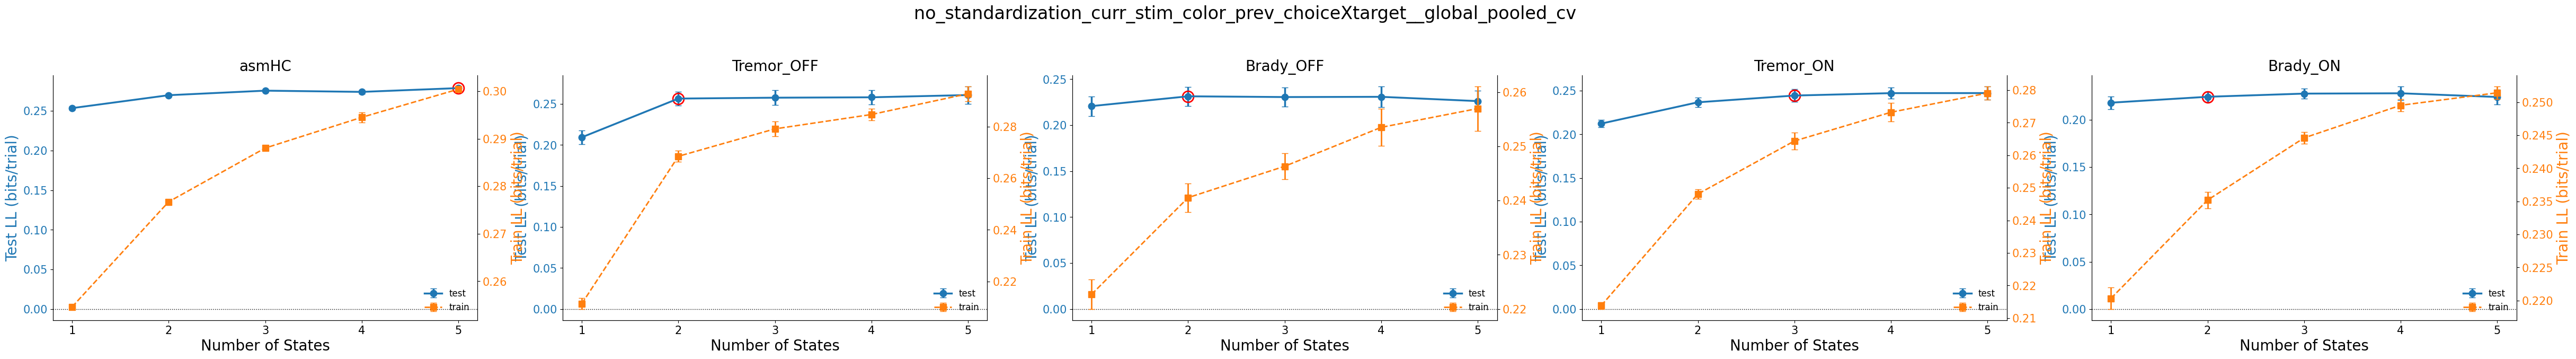

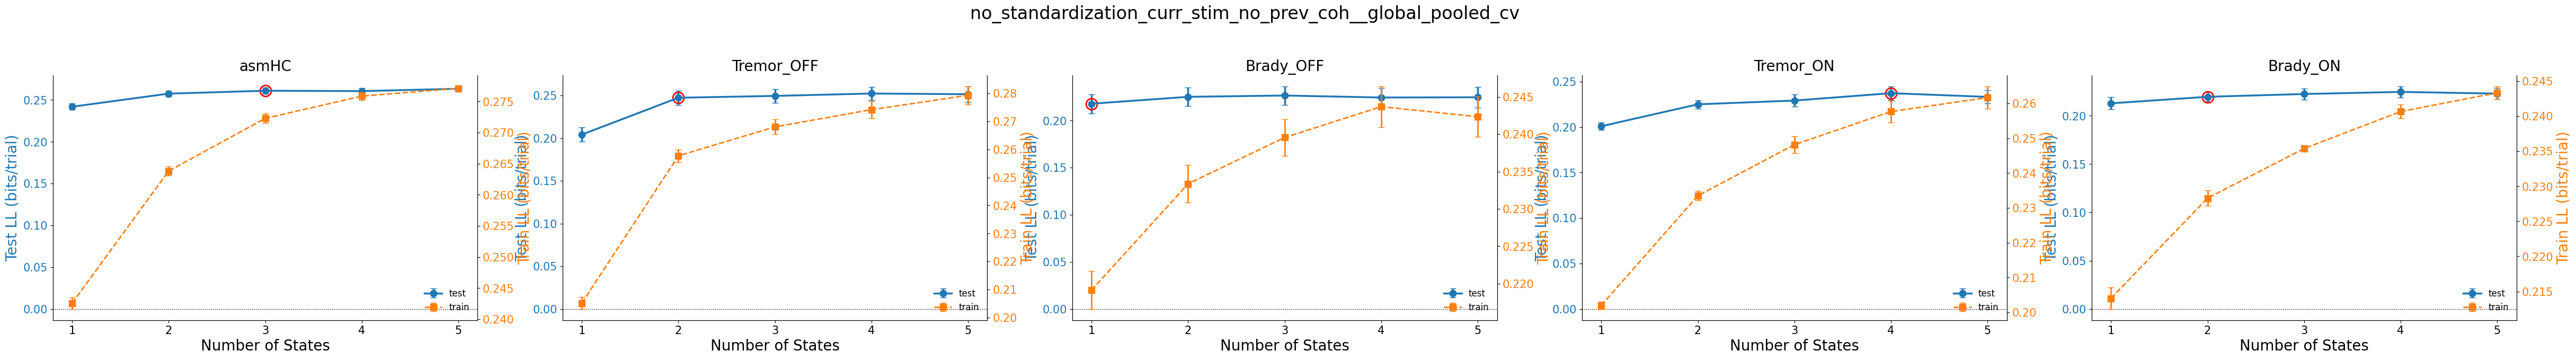

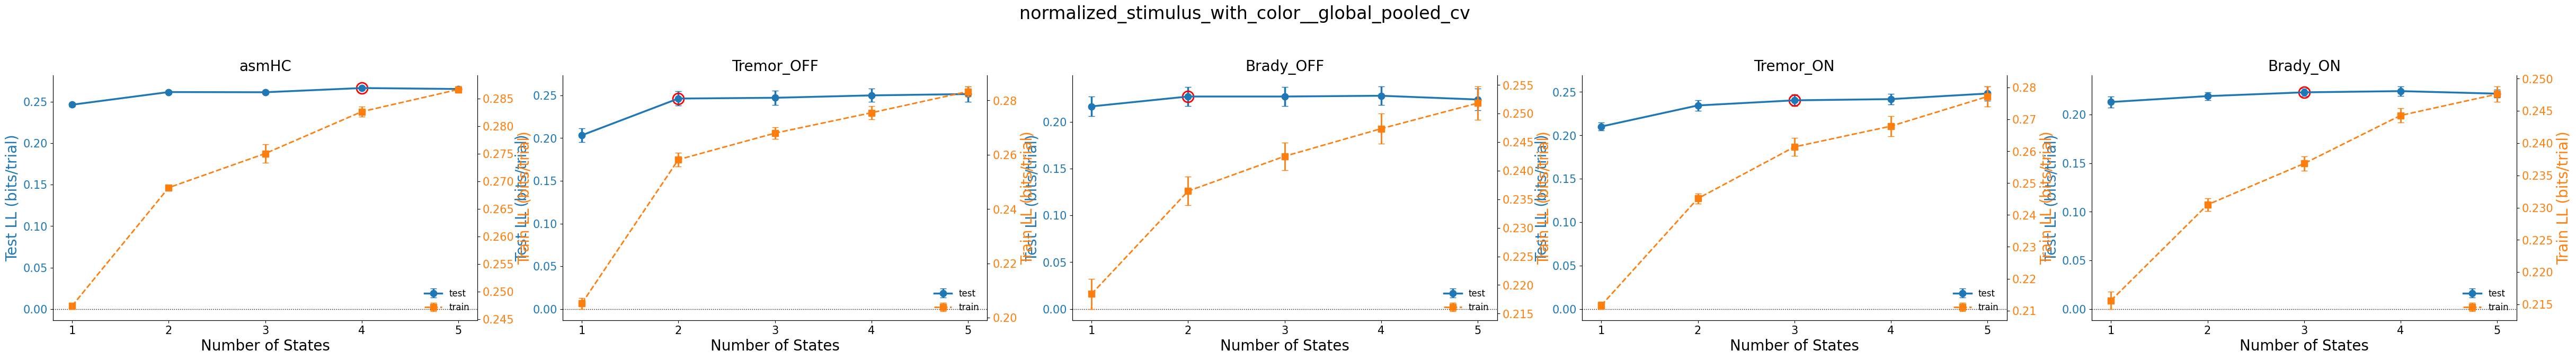

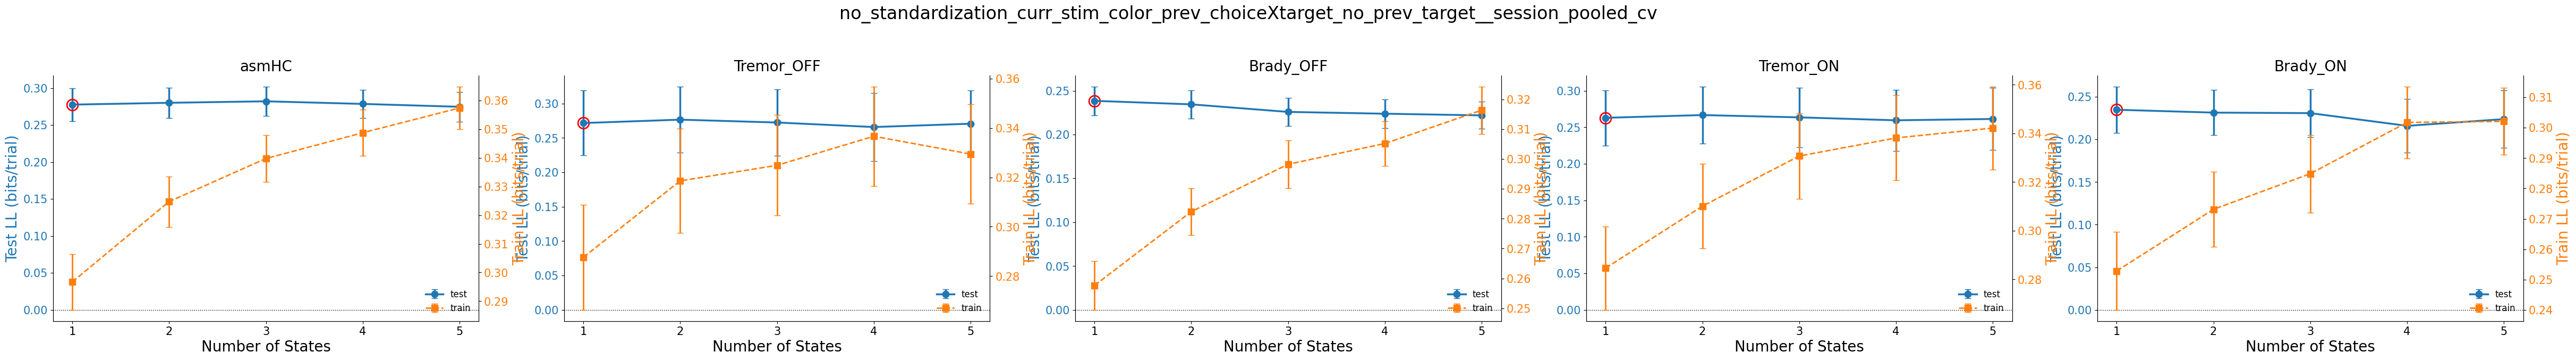

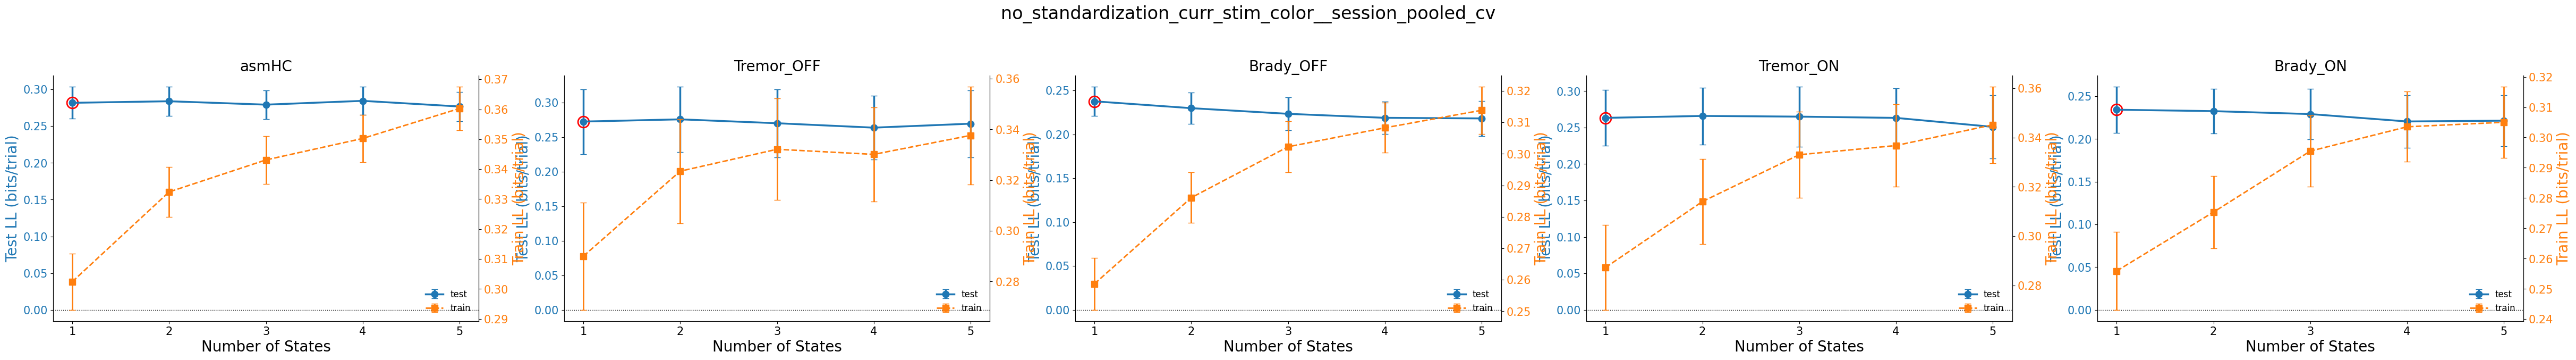

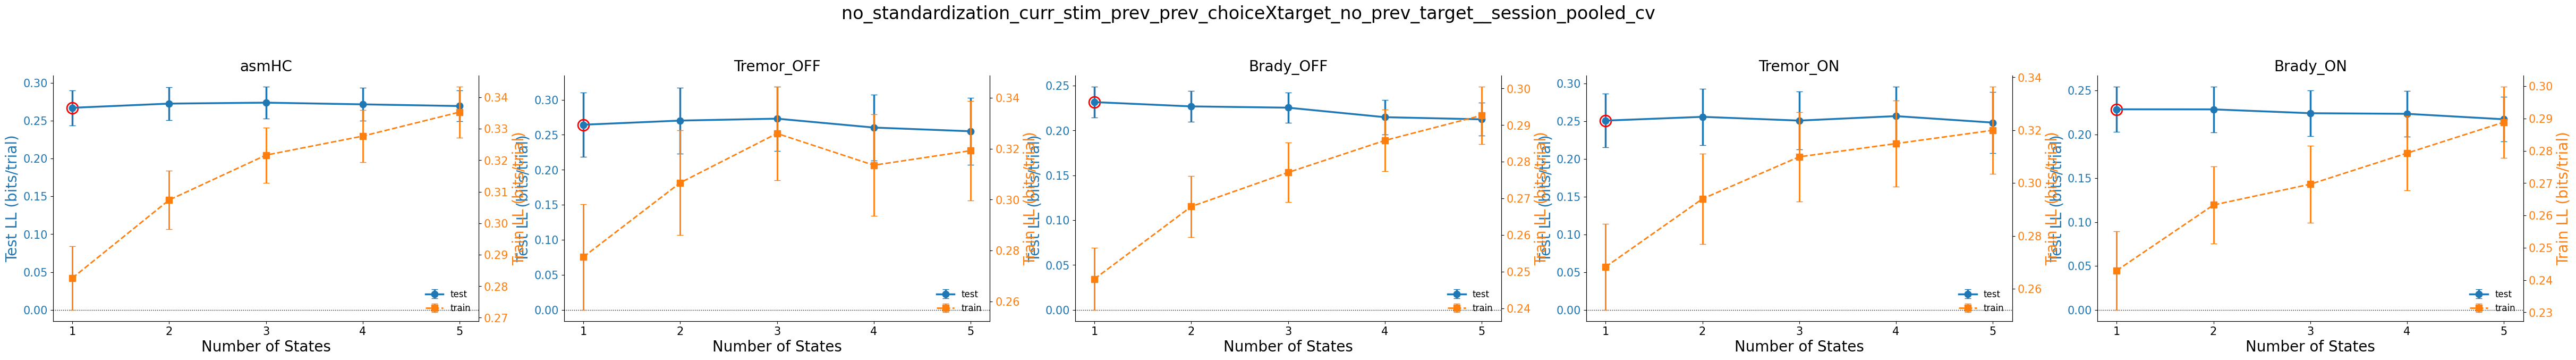

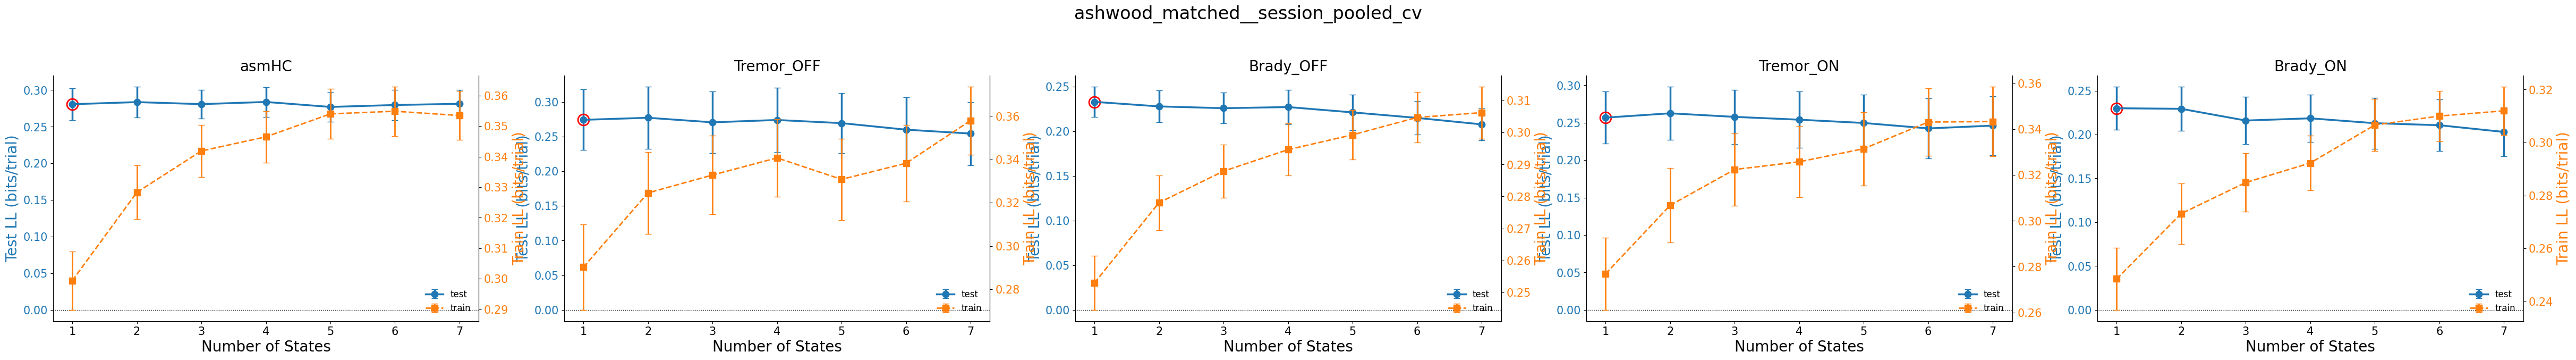

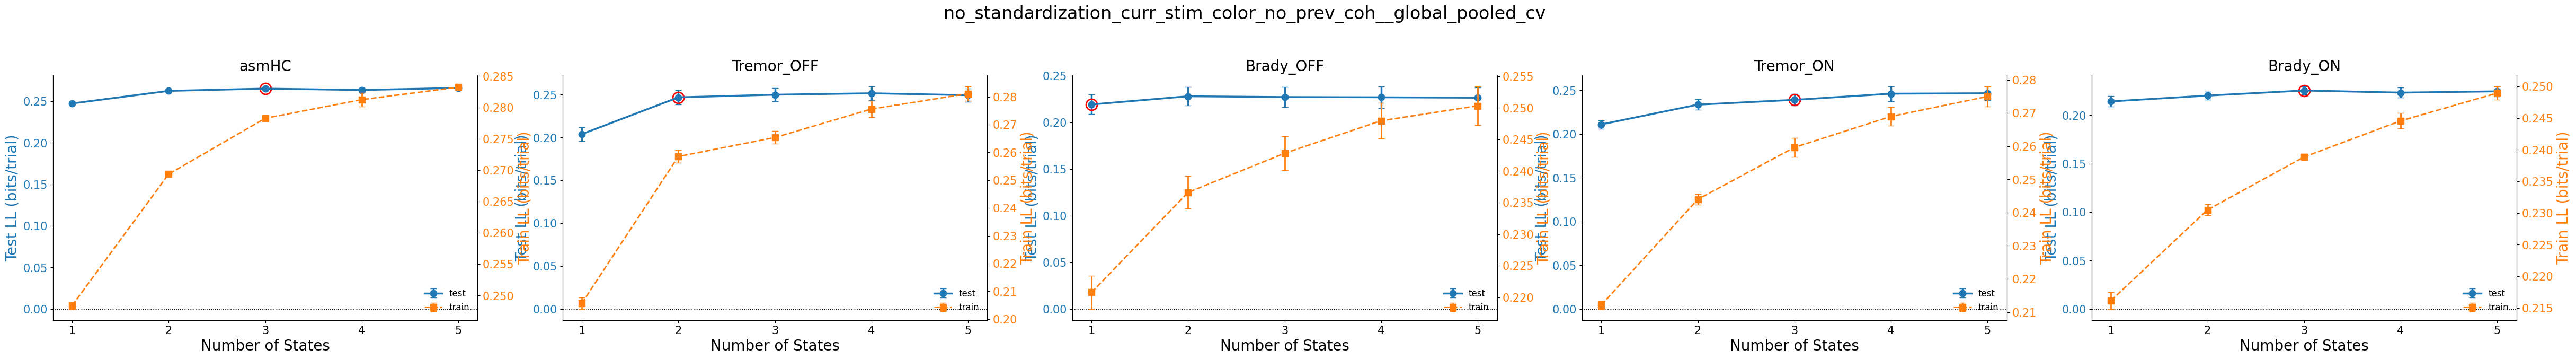

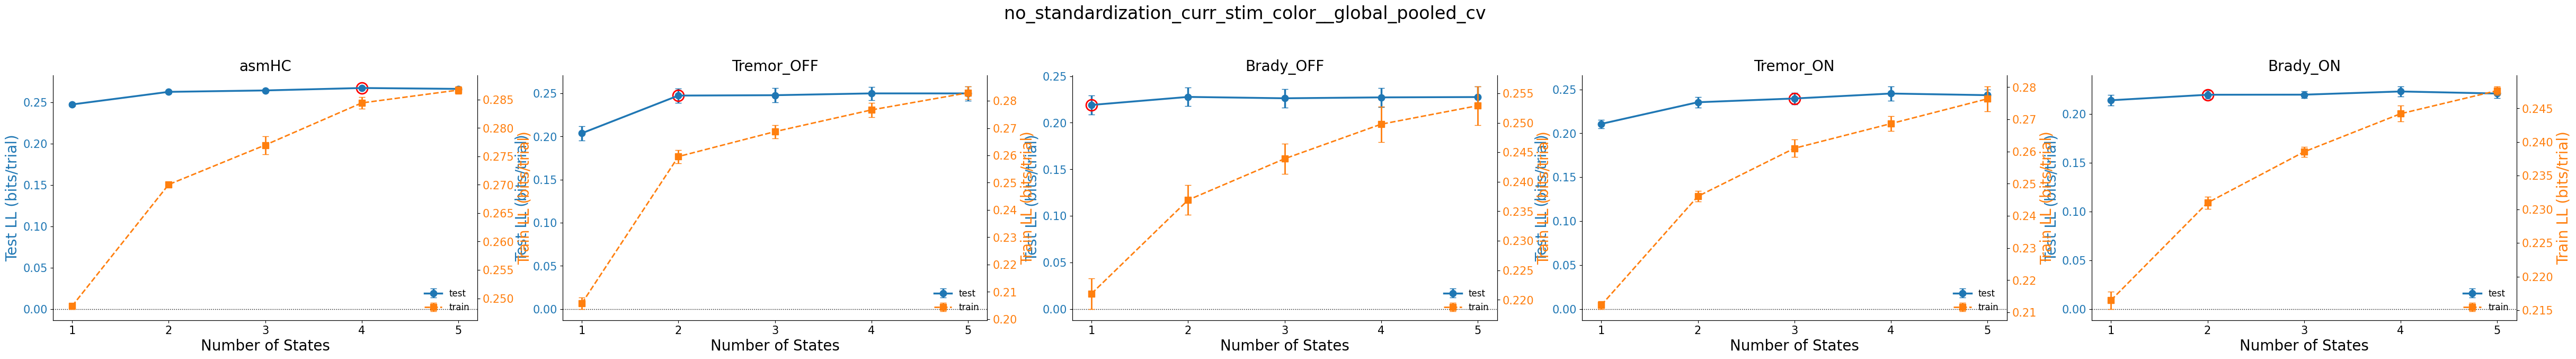

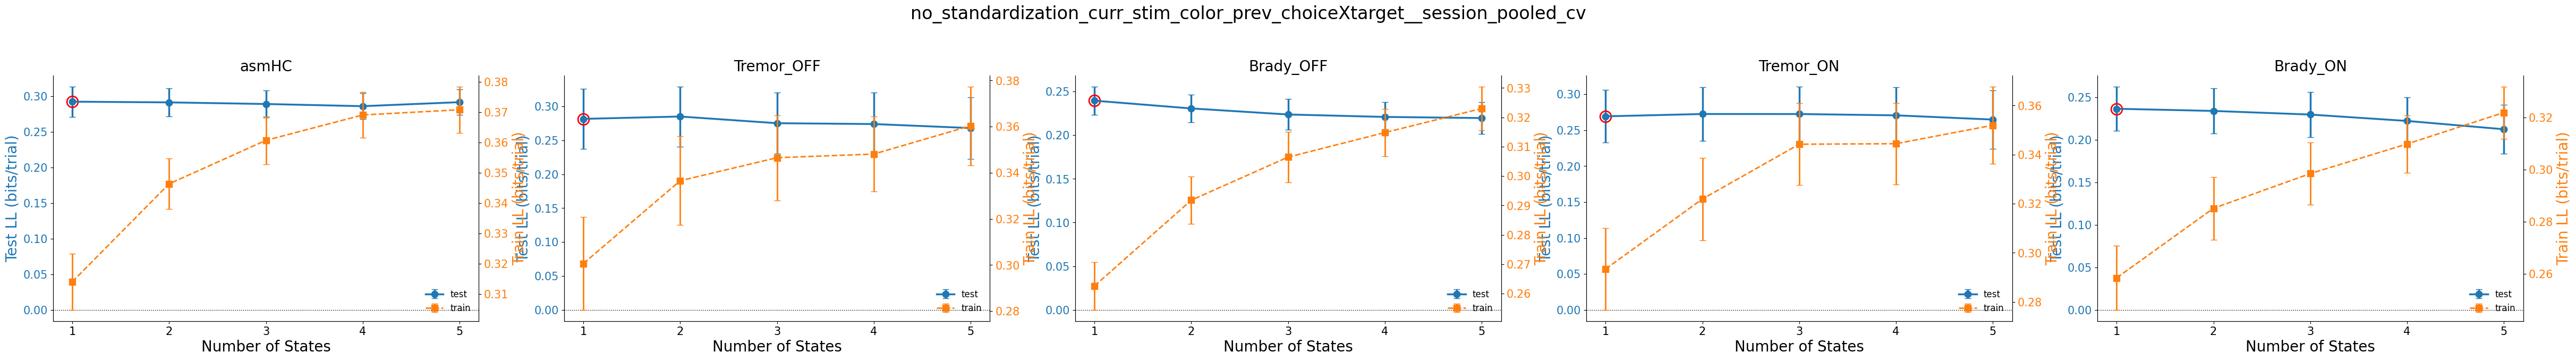

In [18]:
desired_order = ["asmHC", "Tremor_OFF", "Brady_OFF", "Tremor_ON", "Brady_ON"]
order_map = {name: i for i, name in enumerate(desired_order)}

for model_name, model_path in MODEL_PATHS.items():

    cv_type = "pooled_cv" if model_name.endswith("__global_pooled_cv") else "session_cv"

    if cv_type == "pooled_cv":
        test_ll_fn, train_ll_fn = pooled_bits, pooled_train_bits
    elif cv_type == "session_cv":
        test_ll_fn, train_ll_fn = session_bits, session_train_bits

    # Only the base <group>.pkl CV bundles; skip the <group>_final.pkl finetuned models from 5.30.
    base_pkls = [p for p in model_path.glob("*.pkl") if not p.stem.endswith("_final")]

    fig, axs = plt.subplots(1, 5, figsize=(60, 6))
    groups = {}
    for i, subtype_model in enumerate(sorted(base_pkls, key=lambda p: order_map.get(p.stem, float("inf")))):
        group_name = subtype_model.stem
        if subtype_model.stat().st_size == 0:
            print(f"  ! skipping empty/corrupt pickle (needs refitting): {model_name}/{subtype_model.name}")
            continue
        with open(subtype_model, "rb") as f:
            groups[group_name] = pickle.load(f)

        states, mean_bits, sem_bits = test_ll_fn(groups[group_name])
        _, train_mean, train_sem = train_ll_fn(groups[group_name])
        best_k, _ = parsimonious_k(states, mean_bits, sem_bits)

        groups[group_name]["best_k"] = best_k

        plot_test_ll_bits(states, mean_bits, sem_bits, title=f"{group_name}", ax=axs[i], best_k=best_k, train=(train_mean, train_sem))

    fig.suptitle(f"{model_name}", fontsize=24, y=1.1)
    fig.savefig(model_path / "model_selection.png", bbox_inches="tight")

## Sanity check: session CV always collapses to K=1

Session CV is excluded from the config comparison above because it is not comparable to pooled CV
(far less training data per fit, different generalization question). The table below confirms
the expected failure mode: every (config, group) pair selects K=1, meaning per-session data is
too sparse to recover multi-state structure. This motivates using pooled CV for all selection.

In [19]:
rows_session = []
for model_name, model_path in MODEL_PATHS.items():
    if not model_name.endswith("__session_pooled_cv"):
        continue
    config_name = model_name.replace("__session_pooled_cv", "")
    for pkl_path in sorted(
        (p for p in model_path.glob("*.pkl") if not p.stem.endswith("_final") and p.stat().st_size > 0),
        key=lambda p: desired_order.index(p.stem) if p.stem in desired_order else 99,
    ):
        bundle = pickle.load(open(pkl_path, "rb"))
        states, mean_bits, sem_bits = session_bits(bundle)
        best_k, _ = parsimonious_k(states, mean_bits, sem_bits)
        rows_session.append(dict(config=config_name, group=pkl_path.stem, best_k=best_k))

df_sess = pd.DataFrame(rows_session)
pivot_sess_k = df_sess.pivot(index="config", columns="group", values="best_k").reindex(columns=desired_order)
print("Session CV — best_k per (config, group)  (expect all 1s)\n")
print(pivot_sess_k.to_string())
all_one = (pivot_sess_k == 1).all().all()
print(f"\nAll K=1: {all_one}  {'✓ confirms per-session data is too sparse for multi-state recovery' if all_one else '⚠ some sessions recovered K>1 — worth investigating'}")

include__session_pooled_cv = False if all_one == True else True

Session CV — best_k per (config, group)  (expect all 1s)

group                                                                 asmHC  Tremor_OFF  Brady_OFF  Tremor_ON  Brady_ON
config                                                                                                                 
ashwood_matched                                                           1           1          1          1         1
no_standardization_curr_stim                                              1           1          1          1         1
no_standardization_curr_stim_color                                        1           1          1          1         1
no_standardization_curr_stim_color_no_prev_coh                            1           1          1          1         1
no_standardization_curr_stim_color_prev_choiceXtarget                     1           1          1          1         1
no_standardization_curr_stim_color_prev_choiceXtarget_no_prev_target      1           1          1    

## Cross-config comparison

For each **pooled-CV** model, extract the held-out bits/trial at the parsimonious `best_k`
and compare across all configs and groups in one view.

Session-CV models are excluded — they always collapse to K=1 and aren't useful here.

**How to read:**
- Higher bits/trial = better generalisation vs the Bernoulli (coin-flip) null.
- The K label inside each bar is the chosen state count for that (config, group).
- Prefer the config whose bars are consistently tallest; use the 1-SEM rule for ties
  (within ~0.001 bits/trial is practically equivalent).
- If two configs are tied, prefer fewer features (no color if color isn't a research variable).

Pooled CV — bits/trial at best_k  (higher = better, sorted by mean across groups)

group                                                                         asmHC     Tremor_OFF      Brady_OFF      Tremor_ON       Brady_ON    mean
config                                                                                                                                                 
no_standardization_curr_stim_color_prev_choiceXtarget                 0.2788  (K=5)  0.2565  (K=2)  0.2314  (K=2)  0.2444  (K=3)  0.2243  (K=2)  0.2471
ashwood_matched                                                       0.2733  (K=6)  0.2566  (K=3)  0.2281  (K=2)  0.2333  (K=3)  0.2252  (K=3)  0.2433
no_standardization_curr_stim_prev_choiceXtarget                       0.2700  (K=3)  0.2575  (K=2)  0.2285  (K=2)  0.2334  (K=3)  0.2242  (K=2)  0.2427
no_standardization_curr_stim_color_prev_choiceXtarget_no_prev_target  0.2707  (K=4)  0.2548  (K=3)  0.2185  (K=1)  0.2440  (K=4)  0.2200  (K=2)  0.2416
norma

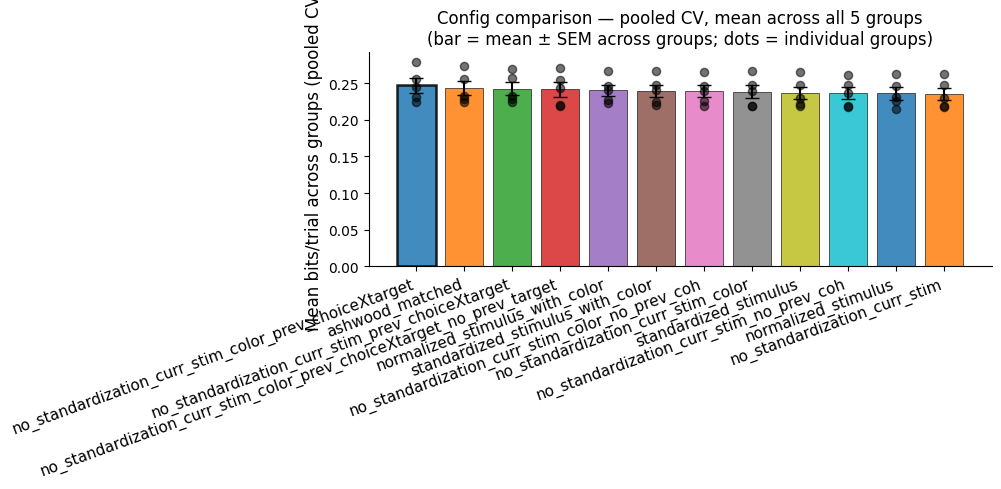

In [20]:
desired_order = ["asmHC", "Tremor_OFF", "Brady_OFF", "Tremor_ON", "Brady_ON"]

# ── Collect bits/trial at best_k — pooled CV only ─────────────────────────────
rows = []
for model_name, model_path in MODEL_PATHS.items():

    if not include__session_pooled_cv and model_name.endswith("__session_pooled_cv"):
        continue

    config_name = model_name.replace("__global_pooled_cv", "")
    for pkl_path in sorted(
        (p for p in model_path.glob("*.pkl") if not p.stem.endswith("_final") and p.stat().st_size > 0),
        key=lambda p: desired_order.index(p.stem) if p.stem in desired_order else 99,
    ):
        bundle = pickle.load(open(pkl_path, "rb"))
        states, mean_bits, sem_bits = pooled_bits(bundle)
        best_k, _ = parsimonious_k(states, mean_bits, sem_bits)
        best_idx = int(np.where(states == best_k)[0][0])
        rows.append(dict(config=config_name, group=pkl_path.stem,
                         best_k=best_k, bits=mean_bits[best_idx], sem=sem_bits[best_idx]))

df_cmp = pd.DataFrame(rows)

# ── Summary table sorted by mean bits/trial across groups ─────────────────────
pivot_bits = df_cmp.pivot(index="config", columns="group", values="bits").reindex(columns=desired_order)
pivot_k    = df_cmp.pivot(index="config", columns="group", values="best_k").reindex(columns=desired_order)
pivot_bits["mean"] = pivot_bits.mean(axis=1)
cell_text = (
    pivot_bits.drop(columns="mean").map(lambda v: f"{v:.4f}")
    + "  (K=" + pivot_k.map(lambda v: str(int(v))) + ")"
)
cell_text["mean"] = pivot_bits["mean"].map(lambda v: f"{v:.4f}")
cell_text = cell_text.sort_values("mean", ascending=False)
print("Pooled CV — bits/trial at best_k  (higher = better, sorted by mean across groups)\n")
print(cell_text.to_string())
print(f"\nBest overall config: {cell_text.index[0]}  ({cell_text['mean'].iloc[0]} bits/trial avg)")

# ── Chart: one bar per config, mean across groups ± SEM; group dots overlaid ──
configs_sorted = cell_text.index.tolist()
group_bits     = pivot_bits.drop(columns="mean").reindex(configs_sorted)
means = group_bits.mean(axis=1).values
sems  = group_bits.sem(axis=1).values

config_colors = {c: plt.cm.tab10.colors[i % 10] for i, c in enumerate(configs_sorted)}

fig, ax = plt.subplots(figsize=(10, 5))
for i, config in enumerate(configs_sorted):
    is_best = i == 0
    ax.bar(i, means[i], color=config_colors[config], alpha=0.85,
           edgecolor="black", linewidth=1.8 if is_best else 0.5)
    ax.errorbar(i, means[i], yerr=sems[i], color="black", capsize=5, linewidth=1.5, zorder=5)
    for group in desired_order:
        ax.scatter(i, group_bits.loc[config, group], color="black", s=35, zorder=6, alpha=0.55)

ax.set_xticks(range(len(configs_sorted)))
ax.set_xticklabels(configs_sorted, rotation=20, ha="right", fontsize=11)
ax.set_ylabel("Mean bits/trial across groups (pooled CV)", fontsize=12)
ax.set_title("Config comparison — pooled CV, mean across all 5 groups\n"
             "(bar = mean ± SEM across groups; dots = individual groups)", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(glm_hmm_dir / "cross_config_comparison.png", bbox_inches="tight", dpi=150)
plt.show()

In [21]:
# ── persist results for combined comparison in 5.24 ───────────────────────────
pivot_bits.rename(columns={"mean": "mean_bits"}).to_csv(
    glm_hmm_dir / "model_selection_bits_per_trial.csv", index=True
)
pivot_k.to_csv(glm_hmm_dir / "model_selection_best_k_bits.csv")